# YOLO26m v1 Object Detection Model Evaluation

This notebook evaluates the YOLO26m v1 object detection model for face mask detection.
- **Model**: face_mask_detection_yolo26m_v1_best.pt
- **Purpose**: Detect faces and classify mask status (detection + classification combined)
- **Evaluation**: IoU-based matching on test set using ground truth annotations

## Setup and Imports

In [29]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

## Define Paths and Load Model

### How to Calculate Model Parameters

**Formula for Dense/Fully Connected Layers:**
```
Parameters = (input_size × output_size) + output_size
           = (input_size × output_size) + bias_terms
```

**Example: Dense(256) after 1280 inputs:**
```
Parameters = (1280 × 256) + 256 = 327,936
```

**Formula for Convolutional Layers:**
```
Parameters = (kernel_height × kernel_width × input_channels × output_channels) + output_channels
```

**Example: Conv2D(3×3, input=32, output=64):**
```
Parameters = (3 × 3 × 32 × 64) + 64 = 18,496
```

**Formula for Batch Normalization:**
```
Parameters = 2 × num_features  (scale + shift parameters)
           + 2 × num_features  (running mean + variance, not trainable)
```

**Example: BatchNorm(256 features):**
```
Parameters = 2 × 256 = 512 (trainable)
```

**Layers with NO Parameters:**
- Activation layers (ReLU, Sigmoid, etc.)
- Dropout layers
- GlobalAveragePooling layers
- Max/Average Pooling layers

In [30]:
# Define paths
BASE_DIR = Path('/Users/khoanguyen/Workspace/UIT/face_mask_detection')
MODEL_PATH = BASE_DIR / 'models' / 'face_mask_detection_yolo26m_v1_best.pt'
TEST_IMAGES_DIR = BASE_DIR / 'datasets' / 'face-mask-detection-processed' / 'images' / 'test'
TEST_LABELS_DIR = BASE_DIR / 'datasets' / 'face-mask-detection-processed' / 'labels' / 'test'

# Class names
CLASS_NAMES = ['With Mask', 'Without Mask', 'Mask Weared Incorrect']

print(f"Model path: {MODEL_PATH}")
print(f"Model exists: {MODEL_PATH.exists()}")
print(f"Test images directory exists: {TEST_IMAGES_DIR.exists()}")
print(f"Test labels directory exists: {TEST_LABELS_DIR.exists()}")

Model path: /Users/khoanguyen/Workspace/UIT/face_mask_detection/models/face_mask_detection_yolo26m_v1_best.pt
Model exists: True
Test images directory exists: True
Test labels directory exists: True


In [31]:
# Load YOLO model
print("Loading YOLOv8m detection model...")
model = YOLO(str(MODEL_PATH))
print("Model loaded successfully!")
print(f"\nModel info:")
print(f"Model type: {type(model)}")

# Get model parameters
total_params = sum(p.numel() for p in model.model.parameters())
trainable_params = sum(p.numel() for p in model.model.parameters() if p.requires_grad)

print(f"\nTotal Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

print(f"\nModel Architecture Summary:")
model.info()

Loading YOLOv8m detection model...
Model loaded successfully!

Model info:
Model type: <class 'ultralytics.models.yolo.model.YOLO'>

Total Parameters: 21,777,514
Trainable Parameters: 0

Model Architecture Summary:
YOLO26m summary: 280 layers, 21,777,514 parameters, 0 gradients, 74.7 GFLOPs


(280, 21777514, 0, 74.73520640000001)

In [32]:
# Create YOLOv8 model info summary
print("\n" + "="*100)
print("YOLOV8M MODEL ARCHITECTURE DETAILS")
print("="*100)

# Get model layers info
model_info = []
for i, module in enumerate(model.model.model):
    try:
        module_name = module.__class__.__name__
        if hasattr(module, 'in_channels'):
            in_ch = module.in_channels if hasattr(module, 'in_channels') else 'N/A'
            out_ch = module.out_channels if hasattr(module, 'out_channels') else 'N/A'
            info_str = f"{module_name} (in: {in_ch}, out: {out_ch})"
        else:
            info_str = module_name
        
        params = sum(p.numel() for p in module.parameters()) if hasattr(module, 'parameters') else 0
        model_info.append({
            'Layer #': i,
            'Module (type)': info_str,
            'Param #': f"{params:,}"
        })
    except:
        pass

if model_info:
    model_df = pd.DataFrame(model_info)
    print(model_df.to_string(index=False))

print("="*100)
print(f"\nTotal Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")


YOLOV8M MODEL ARCHITECTURE DETAILS
 Layer # Module (type)   Param #
       0          Conv     1,856
       1          Conv    73,984
       2          C3k2   111,872
       3          Conv   590,336
       4          C3k2   444,928
       5          Conv 2,360,320
       6          C3k2 1,380,352
       7          Conv 2,360,320
       8          C3k2 1,380,352
       9          SPPF   656,896
      10         C2PSA   990,976
      11      Upsample         0
      12        Concat         0
      13          C3k2 1,642,496
      14      Upsample         0
      15        Concat         0
      16          C3k2   542,720
      17          Conv   590,336
      18        Concat         0
      19          C3k2 1,511,424
      20          Conv 2,360,320
      21        Concat         0
      22          C3k2 1,974,784
      23        Detect 2,803,242

Total Parameters: 21,777,514
Trainable Parameters: 0


## Data Preparation

In [33]:
# Get test images
test_images = sorted(list(TEST_IMAGES_DIR.glob('*.jpg')) + list(TEST_IMAGES_DIR.glob('*.png')))
print(f"Found {len(test_images)} test images")

# Function to read YOLO format labels
def read_yolo_label(label_path):
    """Read YOLO format label file and return list of (class_id, bbox_center_x, bbox_center_y, bbox_w, bbox_h)"""
    labels = []
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    bbox = [float(x) for x in parts[1:]]
                    labels.append((class_id, *bbox))
    return labels

print("Helper functions defined")
print(f"Sample test images:")
for img in test_images[:3]:
    print(f"  {img.name}")

Found 578 test images
Helper functions defined
Sample test images:
  0020.jpg
  0049.jpg
  0054.jpg


## Model Evaluation

In [34]:
# Run predictions on test set with IoU-based matching
print("Running YOLO26m predictions on test set...")
print("(Using IoU-based matching with ground truth)\n")

y_true = []
y_pred = []
confidences = []
ious = []
false_positives = 0
total_ground_truth = 0
total_detections = 0

def convert_yolo_to_pixel_coords(bbox_yolo, img_w, img_h):
    """Convert YOLO format bbox to pixel coordinates"""
    center_x, center_y, bbox_w, bbox_h = bbox_yolo
    pixel_center_x = center_x * img_w
    pixel_center_y = center_y * img_h
    pixel_width = bbox_w * img_w
    pixel_height = bbox_h * img_h
    
    x1 = int(pixel_center_x - pixel_width / 2)
    y1 = int(pixel_center_y - pixel_height / 2)
    x2 = int(pixel_center_x + pixel_width / 2)
    y2 = int(pixel_center_y + pixel_height / 2)
    
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img_w, x2)
    y2 = min(img_h, y2)
    
    return x1, y1, x2, y2

def calculate_iou(box1, box2):
    """Calculate IoU between two boxes"""
    x1_inter = max(box1[0], box2[0])
    y1_inter = max(box1[1], box2[1])
    x2_inter = min(box1[2], box2[2])
    y2_inter = min(box1[3], box2[3])
    
    if x2_inter < x1_inter or y2_inter < y1_inter:
        return 0.0
    
    inter_area = (x2_inter - x1_inter) * (y2_inter - y1_inter)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - inter_area
    
    return inter_area / union_area if union_area > 0 else 0.0

for img_path in tqdm(test_images):
    # Get ground truth labels
    label_path = TEST_LABELS_DIR / (img_path.stem + '.txt')
    gt_labels = read_yolo_label(label_path)
    total_ground_truth += len(gt_labels)
    
    # Read image to get dimensions
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    img_h, img_w = img.shape[:2]
    
    # Run YOLO prediction
    results = model(str(img_path), verbose=False)
    
    # Extract predictions
    pred_boxes = []
    for result in results:
        boxes = result.boxes
        if boxes is not None and len(boxes) > 0:
            for box in boxes:
                xyxy = box.xyxy[0].cpu().numpy()
                x1, y1, x2, y2 = map(int, xyxy)
                pred_class = int(box.cls[0])
                confidence = float(box.conf[0])
                pred_boxes.append((x1, y1, x2, y2, pred_class, confidence))
                total_detections += 1
    
    # Match predictions with ground truth using IoU
    matched_gt = set()
    for pred_box in pred_boxes:
        pred_x1, pred_y1, pred_x2, pred_y2, pred_class, confidence = pred_box
        
        best_iou = 0.5
        best_gt_idx = -1
        best_gt_class = None
        
        for gt_idx, (gt_class, center_x, center_y, bbox_w, bbox_h) in enumerate(gt_labels):
            if gt_idx in matched_gt:
                continue
            
            gt_x1, gt_y1, gt_x2, gt_y2 = convert_yolo_to_pixel_coords(
                (center_x, center_y, bbox_w, bbox_h), img_w, img_h
            )
            iou = calculate_iou((pred_x1, pred_y1, pred_x2, pred_y2), (gt_x1, gt_y1, gt_x2, gt_y2))
            
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx
                best_gt_class = gt_class
        
        if best_gt_class is not None and best_iou > 0.0:
            matched_gt.add(best_gt_idx)
            y_true.append(best_gt_class)
            y_pred.append(pred_class)
            confidences.append(confidence)
            ious.append(best_iou)
        else:
            false_positives += 1

print(f"\n✓ Evaluation complete!")
print(f"\nDetection Statistics:")
print(f"  Total ground truth faces: {total_ground_truth}")
print(f"  Total YOLO detections: {total_detections}")
print(f"  Matched detections: {len(y_pred)}")
print(f"  False positives (no GT match): {false_positives}")
print(f"  False negatives (missed GT): {total_ground_truth - len(y_pred)}")
if total_detections > 0:
    print(f"  Detection Rate: {len(y_pred)/total_ground_truth*100:.2f}%")
    print(f"  False Positive Rate: {false_positives/total_detections*100:.2f}%")
if len(ious) > 0:
    print(f"  Average IoU (matched): {np.mean(ious):.4f}")

Running YOLO26m predictions on test set...
(Using IoU-based matching with ground truth)



100%|██████████| 578/578 [00:11<00:00, 52.33it/s]


✓ Evaluation complete!

Detection Statistics:
  Total ground truth faces: 1393
  Total YOLO detections: 1421
  Matched detections: 1105
  False positives (no GT match): 316
  False negatives (missed GT): 288
  Detection Rate: 79.33%
  False Positive Rate: 22.24%
  Average IoU (matched): 0.7977


## Calculate Metrics

In [35]:
# Calculate overall metrics (on matched detections only)
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

# Per-class metrics
precision_per_class = precision_score(y_true, y_pred, average=None, zero_division=0)
recall_per_class = recall_score(y_true, y_pred, average=None, zero_division=0)
f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0)

print("\n" + "="*80)
print("YOLO26M V1 MODEL - OVERALL METRICS (ON MATCHED DETECTIONS)")
print("="*80)
print(f"Accuracy:        {accuracy:.4f}")
print(f"Precision:       {precision:.4f}")
print(f"Recall:          {recall:.4f}")
print(f"F1-Score:        {f1:.4f}")
print(f"Avg Confidence:  {np.mean(confidences):.4f}")

print("\n" + "="*80)
print("PER-CLASS METRICS")
print("="*80)
for i, class_name in enumerate(CLASS_NAMES):
    if i < len(precision_per_class):
        print(f"\n{class_name}:")
        print(f"  Precision: {precision_per_class[i]:.4f}")
        print(f"  Recall:    {recall_per_class[i]:.4f}")
        print(f"  F1-Score:  {f1_per_class[i]:.4f}")


YOLO26M V1 MODEL - OVERALL METRICS (ON MATCHED DETECTIONS)
Accuracy:        0.9620
Precision:       0.9561
Recall:          0.9620
F1-Score:        0.9583
Avg Confidence:  0.7229

PER-CLASS METRICS

With Mask:
  Precision: 0.9724
  Recall:    0.9877
  F1-Score:  0.9800

Without Mask:
  Precision: 0.9609
  Recall:    0.9556
  F1-Score:  0.9582

Mask Weared Incorrect:
  Precision: 0.4737
  Recall:    0.2812
  F1-Score:  0.3529


## Visualizations

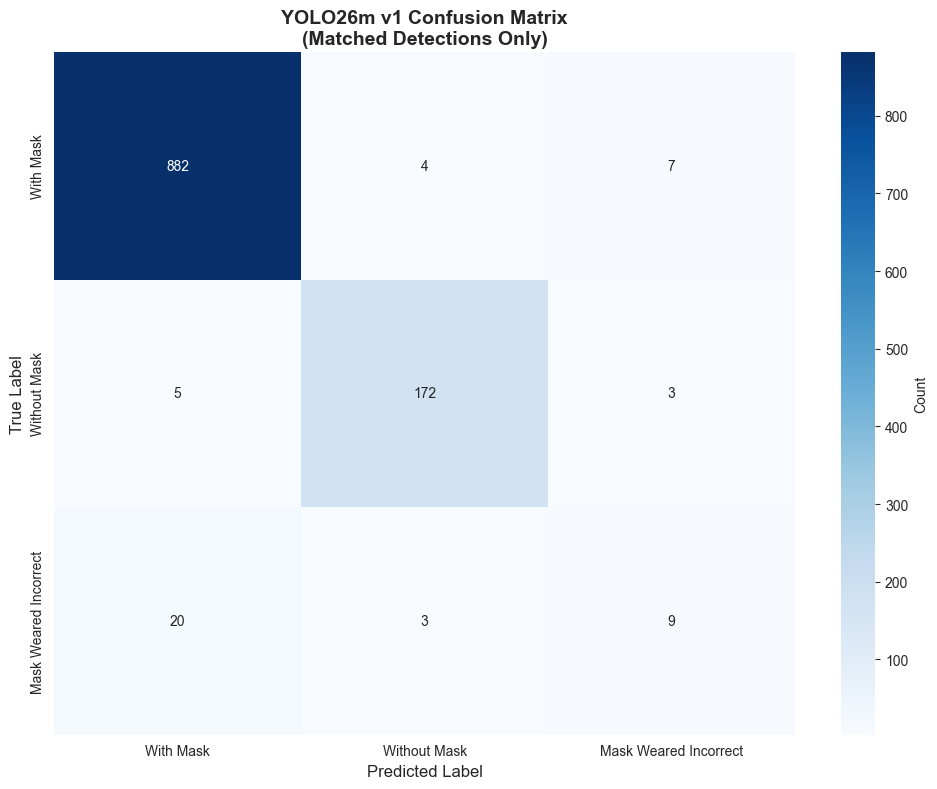

In [36]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Count'})
ax.set_title('YOLO26m v1 Confusion Matrix\n(Matched Detections Only)', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

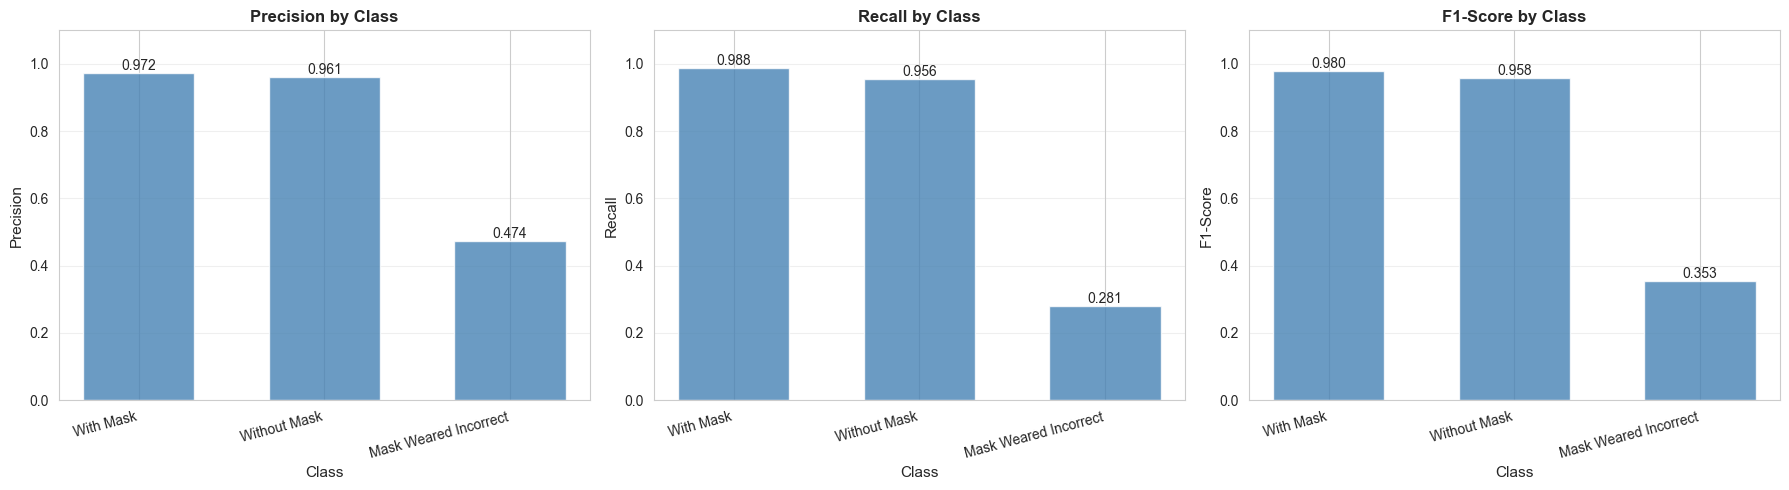

In [37]:
# Per-class metrics visualization
metrics_names = ['Precision', 'Recall', 'F1-Score']
metrics_values = [precision_per_class, recall_per_class, f1_per_class]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (metric_name, metric_vals) in enumerate(zip(metrics_names, metrics_values)):
    ax = axes[idx]
    x = np.arange(len(CLASS_NAMES))
    width = 0.6
    
    # Ensure all classes are represented
    plot_vals = np.zeros(len(CLASS_NAMES))
    for i in range(len(CLASS_NAMES)):
        if i < len(metric_vals):
            plot_vals[i] = metric_vals[i]
    
    bars = ax.bar(x, plot_vals, width, alpha=0.8, color='steelblue')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10)
    
    ax.set_xlabel('Class', fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_title(f'{metric_name} by Class', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

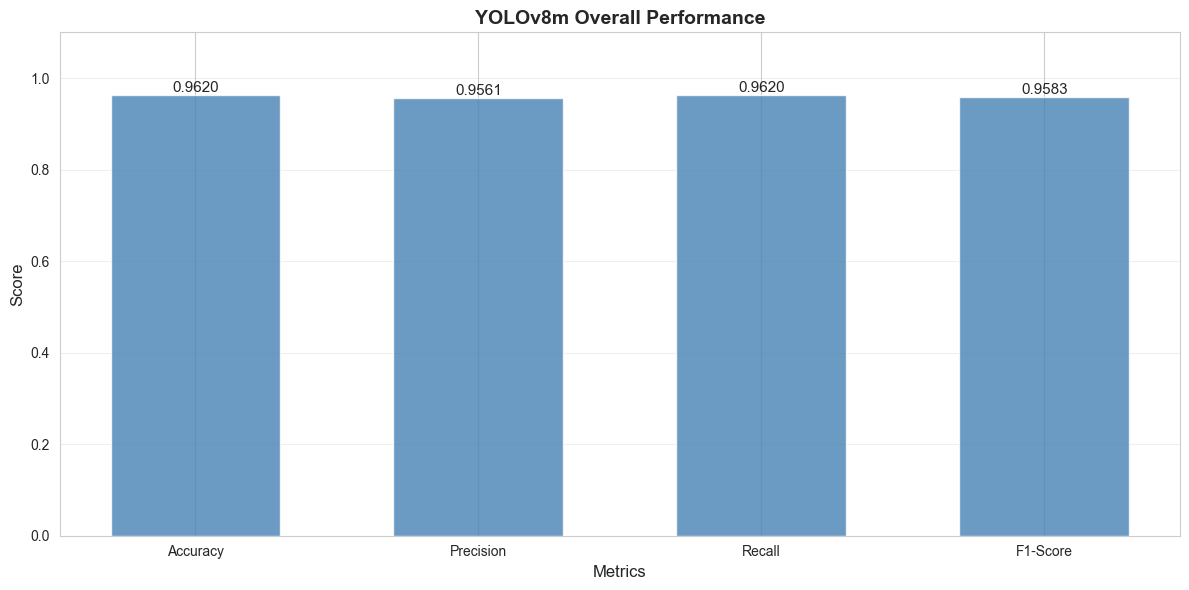

In [38]:
# Overall metrics bar chart
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [accuracy, precision, recall, f1]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics_names))
width = 0.6

bars = ax.bar(x, metrics_values, width, alpha=0.8, color='steelblue')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=11)

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('YOLOv8m Overall Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

## Detailed Classification Report

In [39]:
print("\n" + "="*80)
print("YOLO26M V1 CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_true, y_pred, labels=[0, 1, 2], target_names=CLASS_NAMES, zero_division=0))


YOLO26M V1 CLASSIFICATION REPORT
                       precision    recall  f1-score   support

            With Mask       0.97      0.99      0.98       893
         Without Mask       0.96      0.96      0.96       180
Mask Weared Incorrect       0.47      0.28      0.35        32

             accuracy                           0.96      1105
            macro avg       0.80      0.74      0.76      1105
         weighted avg       0.96      0.96      0.96      1105

